In [416]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import plotly

In [417]:
# Leemos el Data Frame
df = pd.read_csv("afluencia_rtp_cdmx.csv", encoding='latin-1')

# Cambiamos manualmente los caracteres "raros"
# Corrección directa de los nombres afectados
df['servicio'] = df['servicio'].replace({
    'EcobÃºs': 'Ecobús',
    'NochebÃºs': 'Nochebús'
})

In [418]:
# Vemos si hay datos nulos
df.isna().sum()

fecha         24
mes           24
anio          24
servicio      24
tipo_pago      0
afluencia    211
dtype: int64

In [419]:
# Vemos las dimensiones del set de datos
df.shape

(38589, 6)

In [420]:
# Vemos el tipo de dato de cada columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38589 entries, 0 to 38588
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      38565 non-null  str    
 1   mes        38565 non-null  str    
 2   anio       38565 non-null  float64
 3   servicio   38565 non-null  str    
 4   tipo_pago  38589 non-null  str    
 5   afluencia  38378 non-null  float64
dtypes: float64(2), str(4)
memory usage: 1.8 MB


In [421]:
df["anio"].value_counts()

anio
2022.0    9855
2024.0    9072
2023.0    8994
2025.0    8253
2026.0    2391
Name: count, dtype: int64

In [422]:
df.head(20)

,fecha,mes,anio,servicio,tipo_pago,afluencia
0,2022-01-01,Enero,2022.0,Servicios Temporales,Boleto,0.0
1,2022-01-01,Enero,2022.0,Servicios Temporales,Prepago,0.0
2,2022-01-01,Enero,2022.0,Servicios Temporales,Gratuidad,0.0
3,2022-01-01,Enero,2022.0,Atenea,Boleto,2702.0
4,2022-01-01,Enero,2022.0,Atenea,Prepago,0.0
5,2022-01-01,Enero,2022.0,Atenea,Gratuidad,467.0
6,2022-01-01,Enero,2022.0,Ecoatenea,Boleto,0.0
7,2022-01-01,Enero,2022.0,Ecoatenea,Prepago,0.0
8,2022-01-01,Enero,2022.0,Ecoatenea,Gratuidad,0.0
9,2022-01-01,Enero,2022.0,Ecobús,Boleto,5652.0


## Todos los servicios del RTP (de la columna _"servicio"_)
**🚌 1. Servicios Especializados y de Género**
* `Atenea`: Es un servicio exclusivo para mujeres, niños menores de 12 años y personas con discapacidad. Nació para brindar un viaje seguro libre de acoso. (Dato extra para tus conclusiones: Este servicio ha ido disminuyendo e incluso estuvo al borde de la extinción por falta de unidades, verás que su afluencia baja con los años).
* `Ecoatenea`: Es exactamente el mismo concepto del servicio Atenea (exclusivo para mujeres), pero brindado con autobuses de tecnologías limpias, híbridas o ecológicas.
* `Circuito Hospitales`: Rutas circulares de diseño corto destinadas a conectar de forma rápida y accesible los nodos de transporte masivo (como estaciones del Metro) con las principales zonas de centros médicos y hospitales especializados de la CDMX.

**⚡ 2. Servicios de Velocidad o de Ruta Fija**
* `Expreso`: Son autobuses que hacen paradas únicamente en puntos estratégicos o de alta transferencia (como estaciones del Metro o Metrobús) para que el viaje sea mucho más rápido. Su tarifa suele ser un poco más alta que el servicio tradicional.
* `Expdirecto` (Expreso Directo): Es una modalidad aún más estricta que el Expreso. Están pensados para conectar puntos muy lejanos (por ejemplo, de zonas periféricas o altas hacia las terminales del Metro) con paradas mínimas o nulas a mitad del trayecto.
* Ordinario: El servicio base tradicional y más antiguo de la red (los clásicos autobuses verdes). Es de parada diferida, lo que significa que se detiene en absolutamente todas las paradas oficiales de la ruta para dar cobertura total a la población general.

**🌱 3. Servicios Ecológicos y Nocturnos**
* `Ecobús`: Rutas que operan exclusivamente con unidades de bajas emisiones (como autobuses impulsados por Gas Natural Comprimido o unidades 100% eléctricas). Tradicionalmente cubren corredores viales importantes de alta demanda.
* `Nochebús`: El servicio nocturno de la CDMX. Corre en un horario de 12:00 medianoche a 5:00 de la mañana en rutas estratégicas para la gente que trabaja de noche o regresa tarde. Es el que tiene la tarifa más alta por ser horario nocturno.

**🚧 4. Servicios Extraordinarios y de Apoyo**
* `Sustituto de Metro`: Aquí está el gran hallazgo de tu gráfica. Es la flota de apoyo oficial de largo plazo que opera como "línea espejo" sobre la superficie cuando se cierran líneas completas del Metro por remodelaciones mayores programadas. Mueve volúmenes gigantescos de gente.

* `Servicios Temporales`: Rutas de emergencia que RTP abre de forma exprés o contingencias de última hora para dar apoyo ante eventos imprevistos (como una inundación en las vías, fallas eléctricas repentinas o un choque en otros sistemas de transporte).

* `Apoyo Concesionado`: Rutas especiales donde las unidades de RTP entran a cubrir o reforzar el servicio de microbuses o autobuses privados que fueron suspendidos por sanciones, retiro de concesiones por mal servicio o reordenamientos viales de la secretaría.

In [423]:
# Pasamos todo a MAYÚSCULAS y quitamos espacios a los lados
df['servicio'] = df['servicio'].astype(str).str.upper().str.strip()

# Diccionario maestro usando patrones Regex para los casos rebeldes
mapeo_regex = {
    r'.*NOCHEB.*': 'NOCHEBÚS',  # Cualquier texto que contenga "NOCHEB" se vuelve "NOCHEBÚS"
    r'.*ECOB.*': 'ECOBÚS',      # Cualquier texto que contenga "ECOB" se vuelve "ECOBÚS"
    'EXPRESO DIRECTO': 'EXPDIRECTO',
    'APOYO METRO L1': 'SERVICIOS TEMPORALES',
    'APOYO CONCESIONADO': 'APOYO CONCESIONADO',
    'APOYO A CONCESIONADO': 'APOYO CONCESIONADO',
    r'.*CIRCUITO.*': 'CIRCUITO HOSPITALES',  # Cualquier texto que contenga "CIRCUITO" se vuelve "CIRCUITO HOSPITALES"
    'S/METRO': 'SUSTITUTO DE METRO'
}

df['servicio'] = df['servicio'].replace(mapeo_regex, regex=True)

print("--- Conteo de filas por servicio (Totalmente Limpio) ---")
print(df['servicio'].value_counts())

--- Conteo de filas por servicio (Totalmente Limpio) ---
servicio
ATENEA                  5019
ECOBÚS                  4833
NOCHEBÚS                4806
EXPRESO                 4743
ORDINARIO               4743
EXPDIRECTO              4383
SUSTITUTO DE METRO      4269
SERVICIOS TEMPORALES    3351
ECOATENEA               1179
CIRCUITO HOSPITALES      975
APOYO CONCESIONADO       264
Name: count, dtype: int64


In [424]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38589 entries, 0 to 38588
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      38565 non-null  str    
 1   mes        38565 non-null  str    
 2   anio       38565 non-null  float64
 3   servicio   38565 non-null  str    
 4   tipo_pago  38589 non-null  str    
 5   afluencia  38378 non-null  float64
dtypes: float64(2), str(4)
memory usage: 1.8 MB


In [425]:
df["anio"].value_counts()

anio
2022.0    9855
2024.0    9072
2023.0    8994
2025.0    8253
2026.0    2391
Name: count, dtype: int64

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_1186/2654506508.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=afluencia_por_servicio.index,


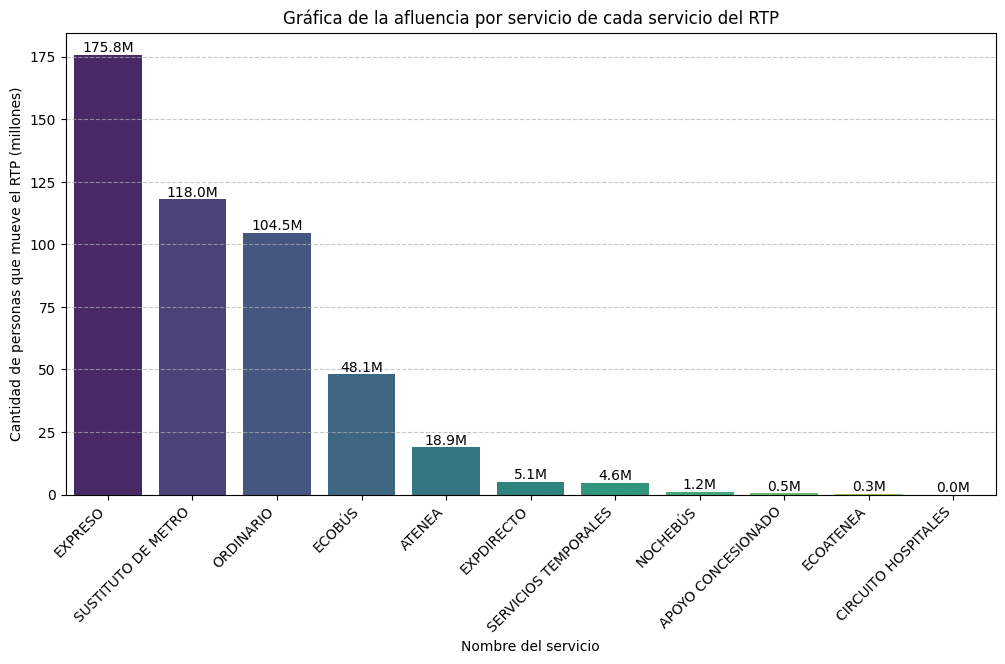

In [426]:
# ----- Agrupación y gráfica de la afluencia por servicio de cada servicio del RTP -----

# Afluencia por servicio
afluencia_por_servicio = df.groupby("servicio")["afluencia"].sum().sort_values(ascending=False).round(2)

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Gráfica de la afluencia por servicio de cada servicio del RTP")
barras = sns.barplot(x=afluencia_por_servicio.index,
                     y=afluencia_por_servicio.values / 1_000_000,
                     palette="viridis")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.1fM')
plt.xlabel("Nombre del servicio")
plt.ylabel("Cantidad de personas que mueve el RTP (millones)")
plt.xticks(rotation=45,
           ha="right")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.7)
plt.show()

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_1186/3522639400.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=afluencia_por_año.index,


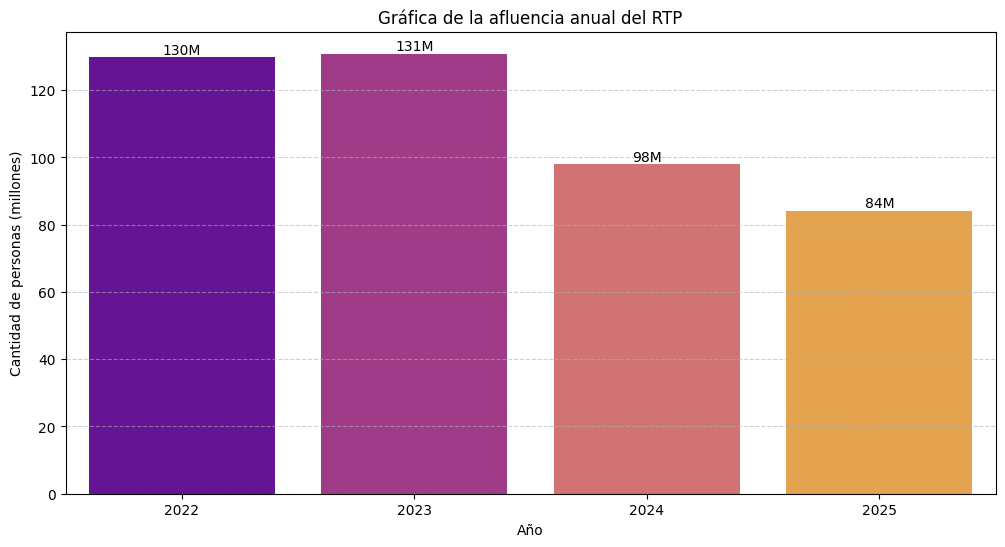

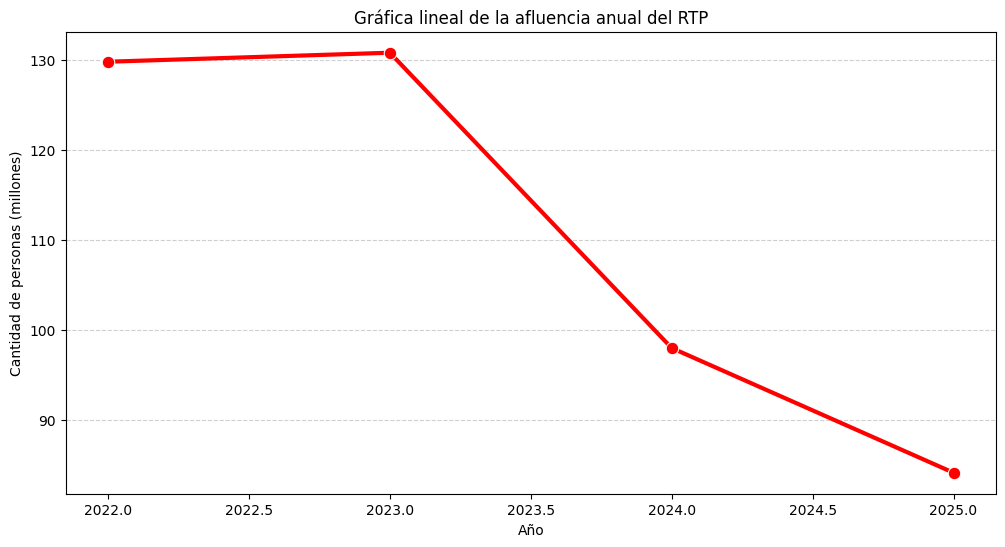

In [429]:
# ----- Agrupación y gráfica de la afluencia por año de cada servicio del RTP -----

# Creamos un nuevo Data Frame sin el año 2026, ya que el 2026 aún no ha acabado
df_sin_2026 = df[df["anio"] != 2026].copy()

# Convertimos la columa "anio" del Data Frame sin el 2026
df_sin_2026["anio"] = df_sin_2026["anio"].astype('Int64')

# Afluencia por año
afluencia_por_año = df_sin_2026.groupby("anio")["afluencia"].sum()

# -- Gráfica de barras acerca de afluencia por cada año del RTP --
plt.figure(figsize=(12,6))
plt.title("Gráfica de la afluencia anual del RTP")
barras = sns.barplot(x=afluencia_por_año.index,
                     y=afluencia_por_año.values / 1_000_000,
                     palette="plasma")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0fM')
plt.xlabel("Año")
plt.ylabel("Cantidad de personas (millones)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

# -- Gráfica lineal de afluencia por cada año del RTP (la misma que la de barras) pero desde otra perspectiva --
plt.figure(figsize=(12,6))
plt.title("Gráfica lineal de la afluencia anual del RTP")
sns.lineplot(x=afluencia_por_año.index,
             y=afluencia_por_año.values / 1_000_000,
             color="red",
             marker="o",
             markersize=9,
             linewidth=3)
plt.xlabel("Año")
plt.ylabel("Cantidad de personas (millones)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()


## 📈🚨 Análisis e Interpretación de la Afluencia Anual (2022 - 2025)
Al analizar la distribución temporal de la afluencia, se observa una marcada **tendencia decreciente** a partir del año 2024, alcanzando su punto más bajo en 2025 con 84.1 millones de pasajeros, lo que representa una reducción de aproximadamente el 35% en comparación con el pico histórico registrado en 2023 (130.8 millones).

1. `Reapertura del metro` Durante los años 2022 y 2023, la Red de Transportes de Pasajeros (RTP) absorbió una carga masiva y extraordinaria de usuarios debido a los cierres programados por modernización profunda y mantenimiento de líneas clave del Sistema de Transporte Colectivo (Metro), tales como la Línea 12, la Línea 1 y la Línea 9. El RTP operó intensamente bajo la modalidad de Sustituto de Metro (S/METRO), funcionando como un "espejo de superficie".